# Part 3. Writing Sample: Geopolitical Shock Transmission in Emerging Bond Markets
## Evidence from Kazakhstan Following the 2022 Russian Invasion of Ukraine
**Author:** Darkhan Mashirapov  
**Last updated:** 2026-08  
**Purpose:** Load the final merged and stationarity-tested dataset produced in Part 2, and
conduct exploratory data analysis — summary statistics, correlation structure, and time
series visualization — split by the pre-war and post-war periods, to establish a
preliminary empirical picture of the research question before formal estimation in
Parts 4-6 (ARDL, Markov-switching, VAR/IRF).

#### Notebook 03 · Block 1 · Load final dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/Results"

levels = pd.read_excel(f"{RESULTS_DIR}/master_dataset_final.xlsx", sheet_name="Levels (Raw)", parse_dates=["date"]).set_index("date")
transformed = pd.read_excel(f"{RESULTS_DIR}/master_dataset_final.xlsx", sheet_name="Transformed (Stationary)", parse_dates=["date"]).set_index("date")
codebook = pd.read_excel(f"{RESULTS_DIR}/master_dataset_final.xlsx", sheet_name="Codebook")

war_onset = pd.Timestamp("2022-02-01")

print(f"Levels shape: {levels.shape}")
print(f"Levels date range: {levels.index.min().date()} to {levels.index.max().date()}")
print(f"\nTransformed shape: {transformed.shape}")
print(f"Transformed date range: {transformed.index.min().date()} to {transformed.index.max().date()}")

print(f"\nLevels columns:\n{levels.columns.tolist()}")
print(f"\nCodebook shape: {codebook.shape}")
display(codebook.head())

Levels shape: (472, 56)
Levels date range: 1987-05-01 to 2026-08-01

Transformed shape: (471, 48)
Transformed date range: 1987-06-01 to 2026-08-01

Levels columns:
['kz_corp_yield_m', 'ru_corp_yield_m', 'kz_govt_yield_1y_m', 'kz_govt_yield_5y_m', 'kz_govt_yield_10y_m', 'ru_govt_yield_1y_m', 'ru_govt_yield_5y_m', 'ru_govt_yield_10y_m', 'kz_tonia_m', 'kz_usdfx_m', 'kz_inflation_yoy_m', 'kz_gdp_m', 'kz_extdebt_m', 'kz_reserves_m', 'kz_m2_m', 'kz_indprod_m', 'kz_unemp_m', 'kz_stockidx_m', 'ru_ruonia_m', 'ru_usdfx_m', 'ru_inflation_yoy_m', 'ru_gdp_m', 'ru_extdebt_m', 'ru_reserves_m', 'ru_m2_m', 'ru_indprod_m', 'ru_unemp_m', 'ru_stockidx_m', 'gl_oil_brent_m', 'gl_gold_m', 'us_yield_1y_m', 'us_yield_5y_m', 'us_yield_10y_m', 'us_fedfunds_m', 'gl_vix_m', 'kz_spread_1y_m', 'kz_spread_5y_m', 'kz_spread_10y_m', 'ru_spread_1y_m', 'ru_spread_5y_m', 'ru_spread_10y_m', 'kz_extdebt_gdp_ratio', 'ru_extdebt_gdp_ratio', 'kz_reserves_m2_ratio', 'ru_reserves_m2_ratio', 'kz_m2_usd', 'ru_m2_usd', 'kz_gdp_usd'

,variable,transform_applied,adf_p_final,kpss_p_final,passed_both_tests
0,kz_corp_yield_m,diff,0.0000,0.1,True
1,ru_corp_yield_m,diff,0.0000,0.1,True
2,kz_govt_yield_1y_m,diff,0.0000,0.1,True
3,kz_govt_yield_5y_m,diff,0.0000,0.1,True
4,kz_govt_yield_10y_m,diff,0.0011,0.1,True


### Note: Levels vs. Transformed column count

The final dataset has 56 columns in the Levels sheet but only 48 in the
Transformed sheet. This 8-column gap is expected, not an error.

The difference corresponds to intermediate helper variables created solely to
construct the fiscal ratios and volatility measures — `kz_m2_usd`, `ru_m2_usd`,
`kz_gdp_usd`, `ru_gdp_usd`, `kz_gdp_annual_usd`, `ru_gdp_annual_usd`,
`kz_stockidx_ret`, `ru_stockidx_ret`. These are retained in the Levels sheet for
full traceability (so the construction of `kz_extdebt_gdp_ratio`,
`kz_reserves_m2_ratio`, and `kz_vol_m`/`ru_vol_m` can be verified directly from
raw inputs), but were never intended as modeling variables in their own right,
so they correctly have no stationarity-transformed counterpart.

The 472 → 471 row difference between the two sheets is the expected consequence
of first-differencing, which necessarily drops the first observation of the
sample.

#### Notebook 03 · Block 2 · Summary Statistics, PRE/POST War split

In [2]:
key_vars = [
    "kz_spread_1y_m", "kz_spread_5y_m", "kz_spread_10y_m",
    "ru_spread_1y_m", "ru_spread_5y_m", "ru_spread_10y_m",
    "kz_vol_m", "ru_vol_m",
]

pre_war = levels.loc[levels.index < war_onset, key_vars]
post_war = levels.loc[levels.index >= war_onset, key_vars]

print(f"Pre-war observations: {len(pre_war)} ({pre_war.index.min().date()} to {pre_war.index.max().date()})")
print(f"Post-war observations: {len(post_war)} ({post_war.index.min().date()} to {post_war.index.max().date()})")

summary_pre = pre_war.describe().T[["count", "mean", "std", "min", "max"]].add_suffix("_pre")
summary_post = post_war.describe().T[["count", "mean", "std", "min", "max"]].add_suffix("_post")

summary_split = pd.concat([summary_pre, summary_post], axis=1)
display(summary_split)

Pre-war observations: 417 (1987-05-01 to 2022-01-01)
Post-war observations: 55 (2022-02-01 to 2026-08-01)


,count_pre,mean_pre,std_pre,min_pre,max_pre,count_post,mean_post,std_post,min_post,max_post
kz_spread_1y_m,27.0,1.112061,0.363726,0.472505,1.912095,55.0,0.326666,1.389114,-2.111264,2.839154
kz_spread_5y_m,27.0,1.077522,0.347563,0.516422,1.624547,55.0,1.692638,0.921073,-0.283966,3.108276
kz_spread_10y_m,27.0,1.056221,0.379545,0.552223,1.770451,55.0,2.328493,0.829664,0.234807,3.628234
ru_spread_1y_m,109.0,1.464386,0.536552,0.102105,2.936667,55.0,1.927967,0.735334,0.371429,4.241364
ru_spread_5y_m,109.0,1.047313,0.591772,-0.173636,2.648571,55.0,1.921844,1.765190,-0.290952,7.335000
ru_spread_10y_m,109.0,0.835085,0.803536,-0.691364,3.117143,55.0,1.913031,2.427579,-1.360476,9.345909
kz_vol_m,256.0,0.047762,0.045565,0.001985,0.313668,55.0,0.026073,0.016440,0.003486,0.083241
ru_vol_m,262.0,0.050429,0.037252,0.003120,0.244156,55.0,0.045502,0.032281,0.005407,0.146220


#### Note: Block 2 — pre/post-war summary statistics

**Sample size caveat:** KZ spreads have only 27 pre-war observations (Nov 2019
– Jan 2022), versus 109 for RU. Comparisons involving KZ's pre-war baseline
should be read with this thin sample in mind throughout the paper.

**Key findings:**
- RU credit spreads rose substantially post-war across all three maturities,
  with both mean and standard deviation increasing sharply (10yr: mean 0.84 →
  1.91, std 0.80 → 2.43) — consistent with H2's expectation of a larger,
  persistent Russian break.
- KZ spreads show a maturity-dependent pattern: the 1yr spread's mean *fell*
  post-war (driven by the negative-spread episode documented earlier), while
  5yr and 10yr spreads rose. This term-structure divergence within Kazakhstan
  itself is a new finding worth carrying into the ARDL specification.
- Stock index volatility fell (KZ) or held roughly flat (RU) on average
  post-war, which is counterintuitive for a shock period and needs visual
  inspection before drawing conclusions — likely reflects a spike-then-settle
  pattern within the post-war window that a simple full-period average masks.

#### Notebook 03 · Block 3 · Correlation heatmaps, pre vs post war

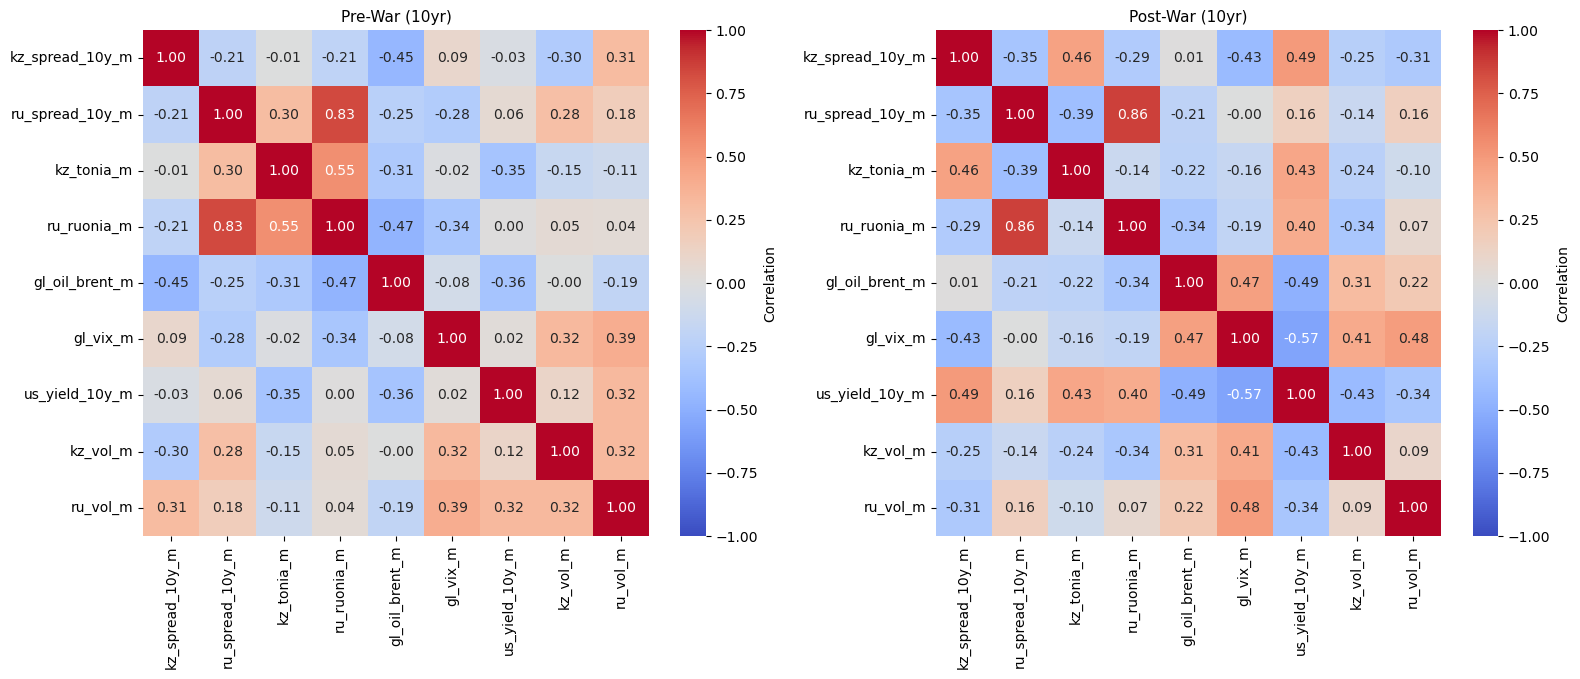


**Figure — 10yr Credit Spread Correlation Matrix (Pre- vs. Post-War)**

Correlation between Kazakhstan's and Russia's 10-year corporate credit spreads and their key macro-financial determinants: domestic interbank liquidity rates (TONIA, RUONIA), global risk factors (Brent oil, VIX, US 10yr Treasury yield), and local stock market volatility.

| | Pre-war | Post-war |
|---|---|---|
| Period | 1987-05-01 to 2022-01-01 | 2022-02-01 to 2026-08-01 |
| Observations (complete cases across all variables) | 27 | 55 |


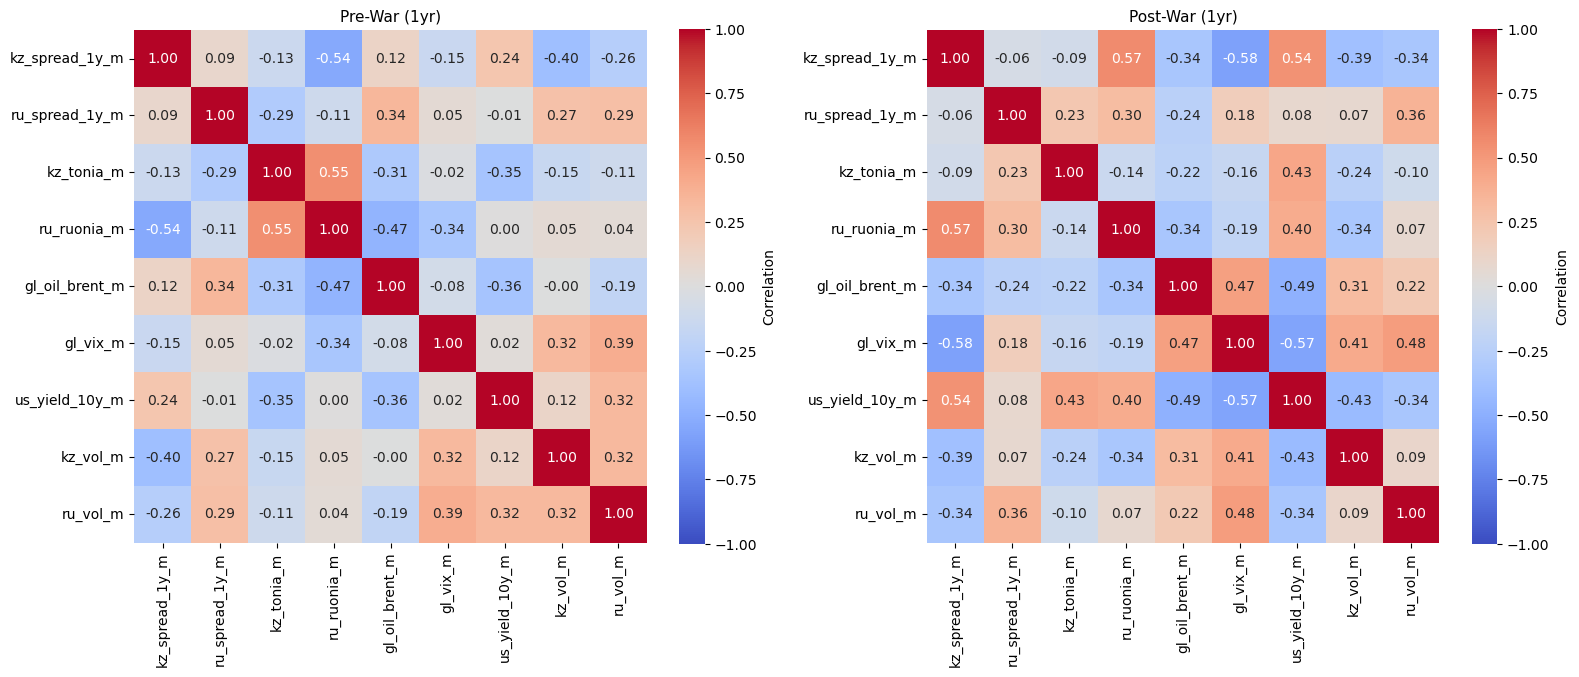


**Figure — 1yr Credit Spread Correlation Matrix (Pre- vs. Post-War)**

Robustness check at the 1yr maturity, using the same driver set as the main 10yr figure above.

| | Pre-war | Post-war |
|---|---|---|
| Period | 1987-05-01 to 2022-01-01 | 2022-02-01 to 2026-08-01 |
| Observations (complete cases across all variables) | 27 | 55 |


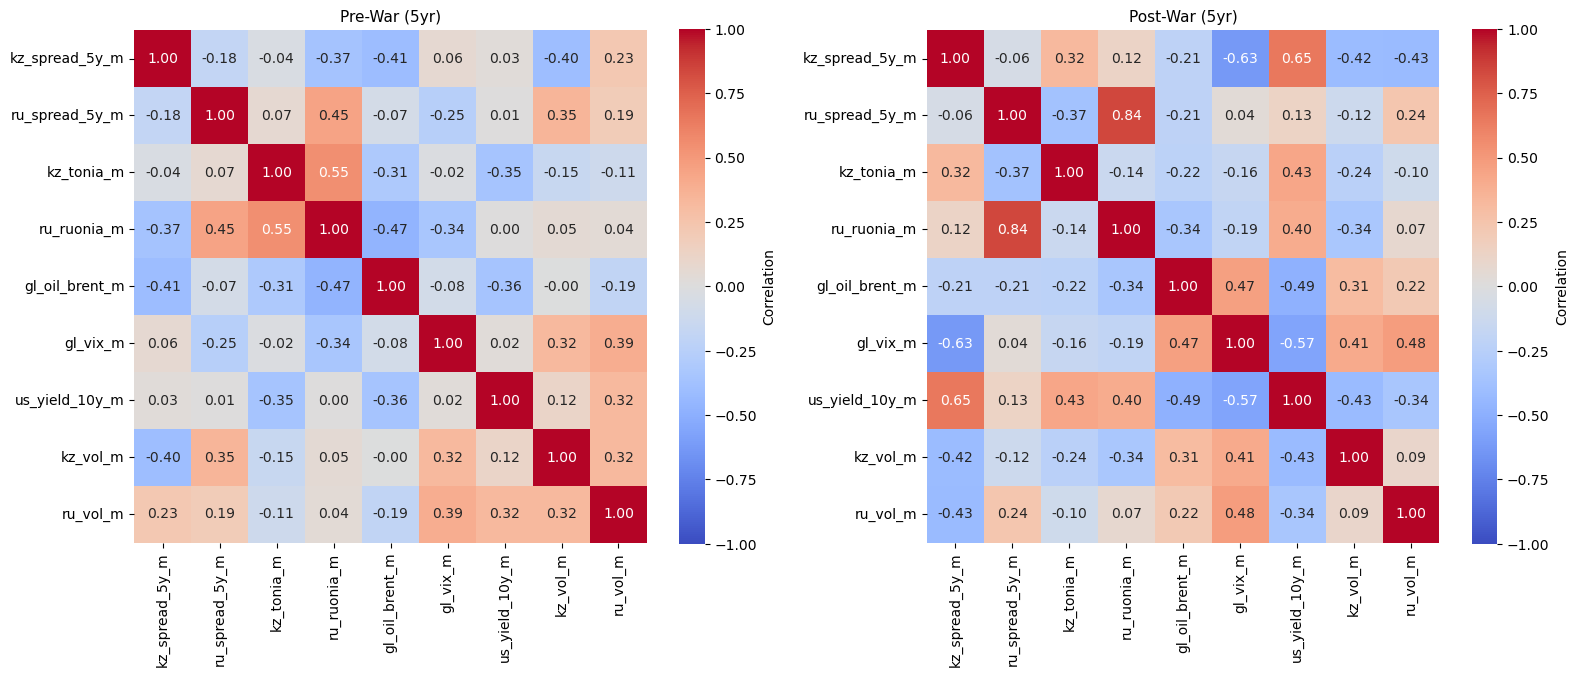


**Figure — 5yr Credit Spread Correlation Matrix (Pre- vs. Post-War)**

Robustness check at the 5yr maturity, using the same driver set as the main 10yr figure above.

| | Pre-war | Post-war |
|---|---|---|
| Period | 1987-05-01 to 2022-01-01 | 2022-02-01 to 2026-08-01 |
| Observations (complete cases across all variables) | 27 | 55 |


In [6]:
import seaborn as sns
from IPython.display import display, Markdown

def plot_corr_pair(vars_list, maturity_label, driver_description):
    pre_data = levels.loc[levels.index < war_onset, vars_list]
    post_data = levels.loc[levels.index >= war_onset, vars_list]

    pre_corr = pre_data.corr()
    post_corr = post_data.corr()

    n_pre = pre_data.dropna().shape[0]
    n_post = post_data.dropna().shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

    sns.heatmap(pre_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                ax=axes[0], square=True, cbar_kws={"label": "Correlation"})
    axes[0].set_title(f"Pre-War ({maturity_label})", fontsize=11)

    sns.heatmap(post_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                ax=axes[1], square=True, cbar_kws={"label": "Correlation"})
    axes[1].set_title(f"Post-War ({maturity_label})", fontsize=11)

    plt.tight_layout()
    plt.show()

    # ── Figure caption block, rendered as markdown beneath the plot ──────────
    caption = f"""
**Figure — {maturity_label} Credit Spread Correlation Matrix (Pre- vs. Post-War)**

{driver_description}

| | Pre-war | Post-war |
|---|---|---|
| Period | {pre_data.index.min().date()} to {pre_data.index.max().date()} | {post_data.index.min().date()} to {post_data.index.max().date()} |
| Observations (complete cases across all variables) | {n_pre} | {n_post} |
"""
    display(Markdown(caption))


# ── Main text figure: 10yr ────────────────────────────────────────────────────
main_vars = [
    "kz_spread_10y_m", "ru_spread_10y_m",
    "kz_tonia_m", "ru_ruonia_m",
    "gl_oil_brent_m", "gl_vix_m", "us_yield_10y_m",
    "kz_vol_m", "ru_vol_m",
]
plot_corr_pair(
    main_vars, "10yr",
    "Correlation between Kazakhstan's and Russia's 10-year corporate credit "
    "spreads and their key macro-financial determinants: domestic interbank "
    "liquidity rates (TONIA, RUONIA), global risk factors (Brent oil, VIX, "
    "US 10yr Treasury yield), and local stock market volatility."
)

# ── Appendix figures: 1yr and 5yr ────────────────────────────────────────────
for maturity, kz_col, ru_col in [("1yr", "kz_spread_1y_m", "ru_spread_1y_m"),
                                   ("5yr", "kz_spread_5y_m", "ru_spread_5y_m")]:
    vars_this_maturity = [kz_col, ru_col, "kz_tonia_m", "ru_ruonia_m",
                           "gl_oil_brent_m", "gl_vix_m", "us_yield_10y_m",
                           "kz_vol_m", "ru_vol_m"]
    plot_corr_pair(
        vars_this_maturity, maturity,
        f"Robustness check at the {maturity} maturity, using the same driver "
        f"set as the main 10yr figure above."
    )

#### Note: Block 3 — 10yr correlation matrix, pre vs. post war

**Sample size:** 27 pre-war observations, 55 post-war (complete cases across
all 9 variables). The pre-war figure is thin, given Kazakhstan's spread series
begins only in late 2019 — read the pre-war matrix as suggestive rather than
precisely estimated.

**Key findings:**
- Kazakhstan's 10yr spread shows a striking oil decoupling: correlation with
  Brent crude fell from -0.45 pre-war to ~0.01 post-war, consistent with a
  loss of the historical (oil-exporter) relationship between fiscal
  strength and credit risk.
- Russia's spread-oil relationship, by contrast, was stable (-0.25 → -0.21),
  suggesting the oil-spread decoupling is specific to Kazakhstan, not a
  regional/global pattern affecting both countries equally.
- Kazakhstan's spread-TONIA (domestic liquidity) correlation strengthened
  substantially (-0.01 → 0.46), suggesting a shift toward domestic liquidity
  conditions as a driver post-war, coinciding with the oil decoupling above.
- Russia's spread-RUONIA relationship remained strong and largely unchanged
  (0.83 → 0.86) both pre- and post-war.
- The KZ-RU spread cross-correlation became more negative (-0.21 → -0.35),
  not closer to zero — this is a distinct finding from "transmission
  mechanism divergence" and should be interpreted carefully as such in the
  writeup, since a stronger inverse relationship is not the same claim as a
  weaker one.

#### Note: Block 3 (continued) — 1yr and 5yr correlation matrices

The 10yr oil-decoupling and liquidity-strengthening pattern does **not** hold
uniformly across maturities — it strengthens with maturity rather than being a
uniform shift:

- **Oil correlation:** 1yr moved *more negative* post-war (0.12 → -0.34,
  opposite direction from decoupling), 5yr showed partial decoupling
  (-0.41 → -0.21), and 10yr showed full decoupling (-0.45 → 0.01). The
  oil-decoupling finding should be described as a longer-horizon phenomenon,
  not a blanket feature of Kazakhstan's credit spread.
- **Domestic liquidity (TONIA) correlation:** 1yr stayed flat (-0.13 → -0.09),
  while 5yr and 10yr both strengthened (-0.04 → 0.32; -0.01 → 0.46) — again,
  a maturity-dependent shift, strongest at the long end.
- **Notable outlier:** `kz_spread_1y_m` vs. `ru_ruonia_m` flipped sign entirely
  (-0.54 pre-war → +0.57 post-war), the largest single swing across all three
  matrices. Given the 1yr spread's earlier-documented negative-value episode
  in 2022-23, this result should be interpreted cautiously — it may partly
  reflect that same anomalous period rather than a stable new relationship.

**Implication for the paper:** the transmission-mechanism shift this analysis
is designed to detect appears to be a maturity-dependent, long-end phenomenon
in Kazakhstan's credit market, not a uniform shift across the curve. This is
itself a substantive finding and should be stated as such, rather than
presenting only the 10yr result as if it generalized.

#### Notebook 03 · Block 4 · Spread time series, KZ vs RU overlaid

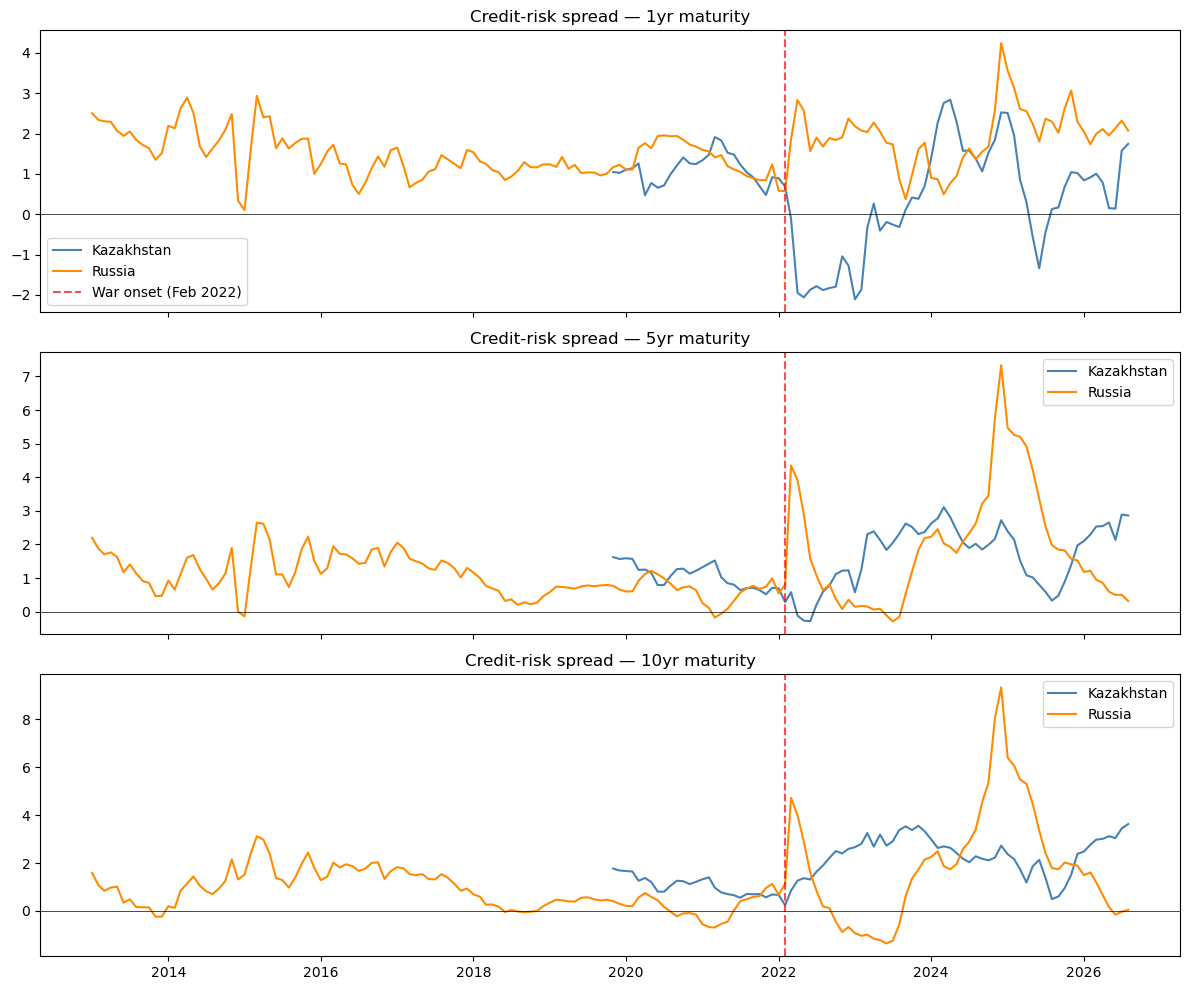

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
pairs = [("kz_spread_1y_m", "ru_spread_1y_m", "1yr"),
         ("kz_spread_5y_m", "ru_spread_5y_m", "5yr"),
         ("kz_spread_10y_m", "ru_spread_10y_m", "10yr")]

for ax, (kz_col, ru_col, label) in zip(axes, pairs):
    ax.plot(levels.index, levels[kz_col], label="Kazakhstan", color="steelblue")
    ax.plot(levels.index, levels[ru_col], label="Russia", color="darkorange")
    ax.axvline(war_onset, color="red", linestyle="--", alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Credit-risk spread — {label} maturity")
    ax.legend()

axes[0].legend(["Kazakhstan", "Russia", "War onset (Feb 2022)"])
plt.tight_layout()
plt.show()

#### Note: Block 4 spread time series, KZ vs RU

**Key visual findings:**
- Russia's spread shows the classic shock signature at war onset: sharp spike
  immediately following Feb 2022 across all three maturities, receding within
  months.
- Kazakhstan's initial reaction is a temporary *drop* into negative territory
  at 1yr/5yr immediately post-war (visually confirming the negative-spread
  episode documented in Section 4.5), followed by a slower, gradual rise
  through 2023-2026 rather than a sharp shock.
- **A second, larger Russian spread spike occurs around 2024-2025** (5yr peaks
  ~7.3, 10yr peaks ~9.3), exceeding the magnitude of the initial Feb 2022
  reaction. This is a substantial finding not currently addressed by the
  paper's single-break (Feb 2022) framing and should be investigated further
  — possibly indicating a second structural break the Markov-switching model
  should be expected to detect, rather than assuming one clean regime change.
- KZ and RU spreads show visually apparent anti-comovement at several points
  post-war (RU high while KZ low, and vice versa), consistent with the
  increasingly negative KZ-RU cross-correlation found in the Section 4.5
  correlation matrices.

**Open question for the paper:** what event(s) drove Russia's 2024-2025 spread
spike? This needs a brief factual note (e.g., referencing sanctions escalation,
bond market developments, or another identifiable event around that period)
before the Markov-switching chapter, so the second regime shift (if detected)
has a documented economic explanation rather than appearing unexplained.

#### Notebook 03 · Block 5 · Rolling KZ-RU Spread Correlation, 12 vs 24 Month

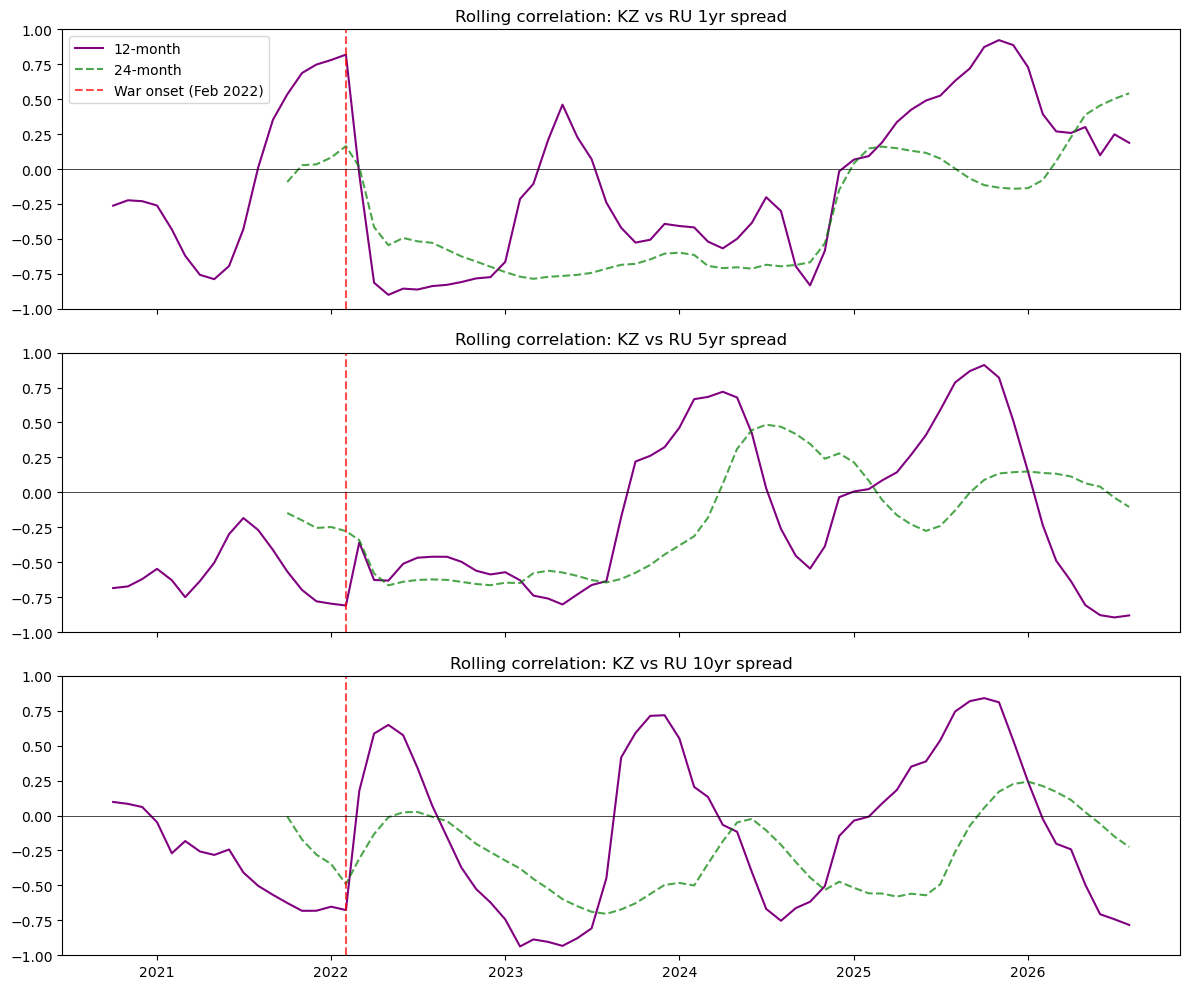

In [13]:
import matplotlib.pyplot as plt

pairs = [("kz_spread_1y_m", "ru_spread_1y_m", "1yr"),
         ("kz_spread_5y_m", "ru_spread_5y_m", "5yr"),
         ("kz_spread_10y_m", "ru_spread_10y_m", "10yr")]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, (kz_col, ru_col, label) in zip(axes, pairs):
    roll_12 = levels[kz_col].rolling(12).corr(levels[ru_col])
    roll_24 = levels[kz_col].rolling(24).corr(levels[ru_col])

    ax.plot(roll_12.index, roll_12, color="purple", label="12-month")
    ax.plot(roll_24.index, roll_24, color="green", linestyle="--", alpha=0.7, label="24-month")
    ax.axvline(war_onset, color="red", linestyle="--", alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylim(-1, 1)
    ax.set_title(f"Rolling correlation: KZ vs RU {label} spread")

axes[0].legend(["12-month", "24-month", "War onset (Feb 2022)"])
plt.tight_layout()
plt.show()

#### Note: Block 5 12-month and 24-month rolling correlation, shown together

Both window lengths are plotted together (12-month solid, 24-month dashed) to
compare directly. The 12-month window reveals genuine cyclical structure that
the 24-month window smooths away: rolling correlation between KZ and RU
spreads swings repeatedly between strongly negative (~ -0.8 to -0.9) and
strongly positive (~+0.65 to +0.85) roughly every 12-18 months post-war,
rather than settling into one stable post-break state.

**Key findings:**
- The 10yr panel shows the clearest cyclical pattern, with correlation swings
  recurring around early 2023, late 2023, early 2025, and late 2025/2026.
- The strongest positive correlation spike in the entire post-war sample
  occurs in the 10yr panel in late 2025 (~0.83, 12-month window), coinciding
  with the second large Russian spread spike identified in Block 4 —
  reinforcing that this 2024-25 episode drove KZ and RU spreads into brief
  alignment rather than further divergence.
- This finding materially changes the paper's framing: the war did not create
  one static "before vs. after" regime for KZ-RU comovement, but rather a
  more volatile, cyclically-shifting relationship that briefly reconverges
  during shared shock episodes. This has direct implications for the
  Markov-switching specification (Notebook 5), which should likely allow for
  more than two regimes, or investigate whether regime transitions are more
  frequent than a single Feb-2022 break would imply.

**Decision:** both windows are retained side by side in the figure — the
24-month line demonstrates how a wider window can obscure the shorter-cycle
dynamics that the 12-month line reveals.

#### Note: Investigation Russia's 2024-2025 spread spike

The second, larger spike in Russia's credit spread identified in the time
series (Block 4) and rolling correlation (Block 5) analyses corresponds to a
documented deterioration in Russian government bond market conditions: Russian
short-term government bond yields reached an all-time high of 22.78% in
December 2024, driven by the Bank of Russia's aggressive monetary tightening
in response to inflation from wartime government spending.

This is best understood as a **structural fiscal story rather than a discrete
sanctions event**: with international debt markets closed by sanctions, the
Russian government has relied increasingly on expensive domestic borrowing,
producing a sustained deterioration — heavy OFZ issuance, a widening budget
deficit driven by defense spending roughly 40% above initial targets, and
debt-service costs projected to consume at least 15% of GDP over the next
decade. This is consistent with a persistent, compounding effect of the war
on Russian credit conditions (supporting H2), rather than the initial 2022
shock alone.

**Implication for the paper:** the war's effect on Russian credit-risk pricing
should be framed as an ongoing structural strain (driven by fiscal and
monetary dynamics tied to sustained wartime spending) rather than a single
February 2022 shock that fully resolved. This has direct implications for the
Markov-switching model (Notebook 5), which may detect a second, distinct
regime shift around late 2024, and for how the paper's conclusion frames
"persistence" in H2.

Source: Trading Economics, Russia 10-Year Government Bond Yield.

#### Notebook 03 · Block 6 · Volatility time series, KZ vs RU

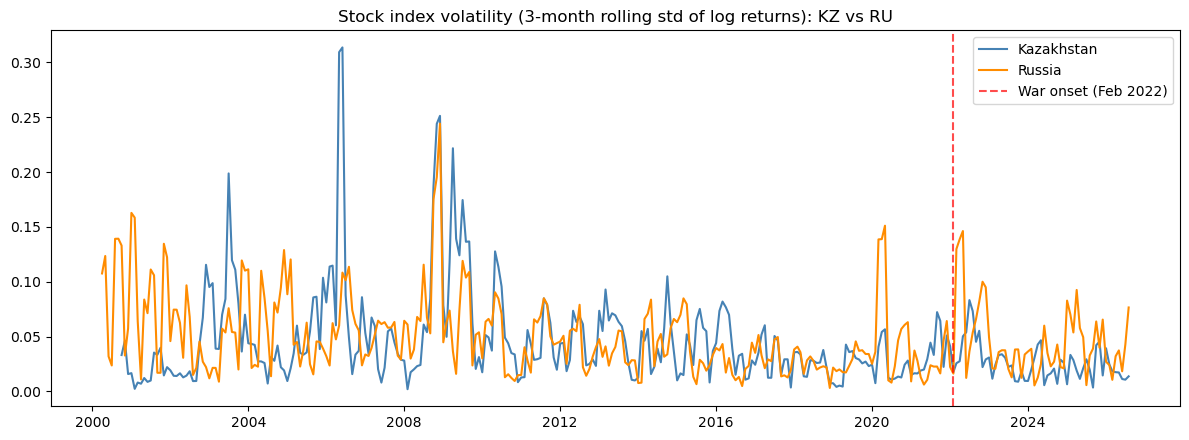

In [14]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(levels.index, levels["kz_vol_m"], label="Kazakhstan", color="steelblue")
ax.plot(levels.index, levels["ru_vol_m"], label="Russia", color="darkorange")
ax.axvline(war_onset, color="red", linestyle="--", alpha=0.7)
ax.set_title("Stock index volatility (3-month rolling std of log returns): KZ vs RU")
ax.legend(["Kazakhstan", "Russia", "War onset (Feb 2022)"])
plt.tight_layout()
plt.show()

### Note: Block 6 — volatility time series, KZ vs RU

**Resolves the Block 2 finding** (average volatility appeared to fall
post-war): the full 26-year series shows the Feb 2022 war-onset volatility
bump is real but modest, and substantially smaller than several earlier
episodes already present in the pre-war sample most notably Kazakhstan's
own 2006 spike (~ 0.31, the largest value in the entire series), and the 2008
global financial crisis (both countries reaching ~ 0.20-0.25). A 2020
COVID-era spike in Russia (~ 0.15) also exceeds the war-onset reaction.

**Implication for the paper:** unlike the credit-spread results, which show
clear and substantial war-specific effects, stock market volatility does not
single out the war as an unusual event relative to KZ/RU's own historical
volatility experience. This is worth stating explicitly rather than
overclaiming it sharpens the paper's argument by clarifying that the war's
detectable impact operates primarily through the credit-spread channel
examined in this analysis, not through broad equity market volatility.

#### Notebook 03 · Block 7 · Distribution check — Transformed dependent variables

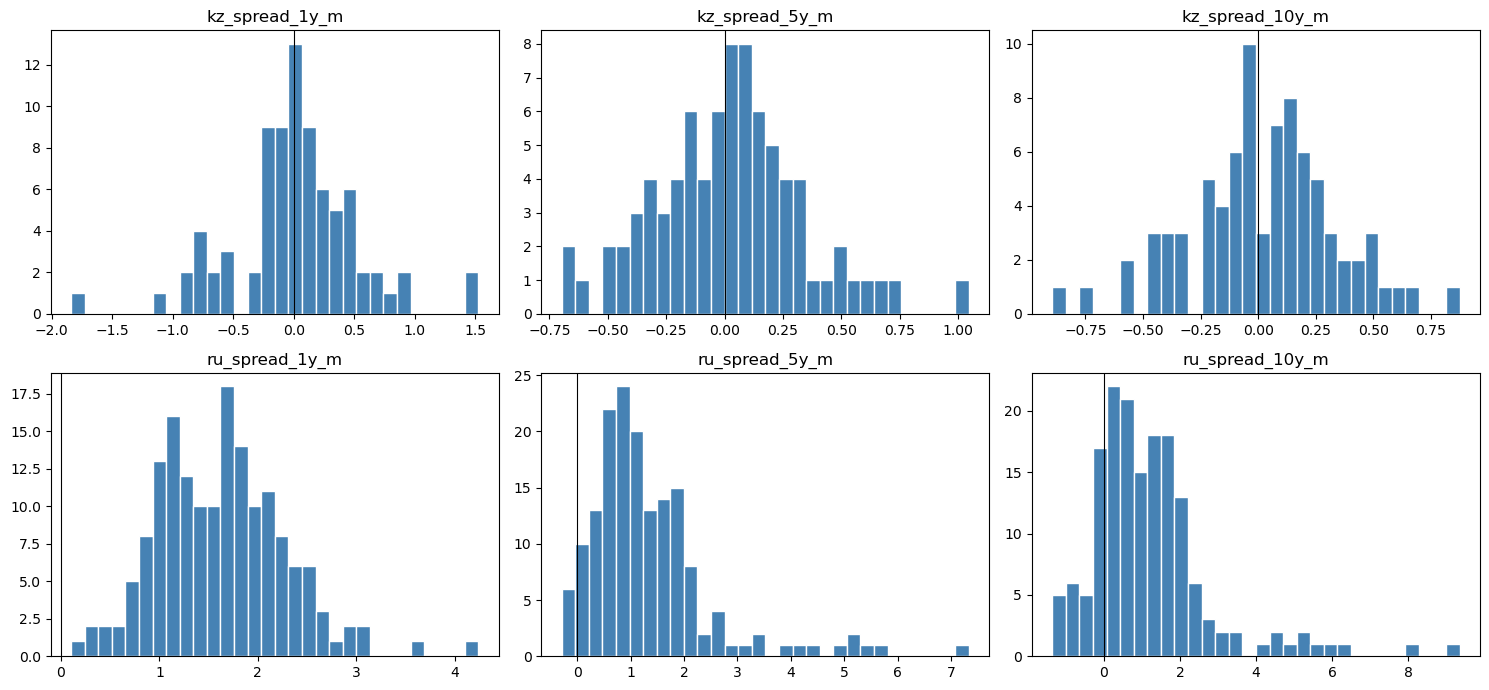

                     mean       std       min       max
kz_spread_1y_m   0.008640  0.515367 -1.840721  1.524787
kz_spread_5y_m   0.015259  0.319561 -0.697283  1.046986
kz_spread_10y_m  0.022936  0.318779 -0.894265  0.874016
ru_spread_1y_m   1.619855  0.646588  0.102105  4.241364
ru_spread_5y_m   1.340601  1.198252 -0.290952  7.335000
ru_spread_10y_m  1.196592  1.625029 -1.360476  9.345909


In [15]:
dep_vars_transformed = [
    "kz_spread_1y_m", "kz_spread_5y_m", "kz_spread_10y_m",
    "ru_spread_1y_m", "ru_spread_5y_m", "ru_spread_10y_m",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, dep_vars_transformed):
    ax.hist(transformed[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

print(transformed[dep_vars_transformed].describe().T[["mean", "std", "min", "max"]])

#### Note: Block 7 — distribution check on transformed dependent variables

**Important labeling clarification:** the six panels are not all the same
kind of quantity. KZ spreads (`kz_spread_1y_m/5y_m/10y_m`) required
first-differencing to achieve stationarity, so their histograms show
**month-to-month changes** (correctly centered near zero, means ~0.01-0.02).
RU spreads passed stationarity testing **at the raw level** (see Block AA
results — `transform_applied = "none_needed"`), so their histograms show
**levels**, not differences (means ~1.2-1.6, matching the raw spread values
themselves). Directly comparing a differenced series against a level series
side by side would otherwise be misleading.

**Distribution shape:**
- KZ panels (differences) are reasonably symmetric, consistent with
  well-behaved stationary series suitable for the ARDL specification.
- RU panels (levels) are right-skewed, with long tails driven by the 2022
  war-onset shock and the 2024-25 fiscal-strain episode (max values of 7.3 and
  9.3 in the 5yr/10yr panels correspond directly to those events).

**Modeling implication:** KZ spreads are integrated of order 1, I(1), while RU
spreads are integrated of order 0, I(0) — a mixed order of integration across
the two countries' dependent variables. Rather than a problem to reconcile,
this is precisely the setting ARDL bounds testing (Pesaran, Shin & Smith,
2001) is designed for: it accommodates a mix of I(0) and I(1) regressors
without requiring all series to share the same order of integration, provided
none are I(2) — which was already confirmed in Notebook 02 (Section 3.5),
where the four I(2) variables were resolved via second-order differencing
before being included in the final dataset. This supports ARDL as the
appropriate modeling choice for Notebook 04, rather than requiring an
alternative unified transformation.

#### Notebook 03 · Block 8 · EDA Summary: Key Findings Before Formal Estimation

This section synthesizes the exploratory findings from Sections 3.1–3.8 into a
single reference point ahead of formal estimation (ARDL, Notebook 04;
Markov-switching, Notebook 05; VAR/IRF, Notebook 06).

#### Sample coverage
Kazakhstan's credit-risk spread series begin only in November 2019, giving a
thin pre-war baseline of 27 observations, versus 109 for Russia (spread series
beginning 2013). All comparisons involving Kazakhstan's pre-war behavior
should be read with this limited sample in mind.

#### Order of integration
Kazakhstan's spreads are I(1) (stationary only after first-differencing);
Russia's spreads are I(0) (stationary at the raw level). This mixed order of
integration across countries is directly compatible with, and indeed the
motivating rationale for, the ARDL bounds-testing framework used in Notebook 04.

#### Pre-war vs. post-war levels and volatility
Russian credit spreads rose substantially post-war across all three
maturities, with mean and standard deviation both increasing sharply
(10yr mean: 0.84 → 1.91; std: 0.80 → 2.43). Kazakhstan's spreads show a
maturity-dependent pattern: the 1yr spread's mean fell post-war (driven by a
documented negative-spread episode in 2022-23), while 5yr and 10yr spreads
rose — indicating the war's effect on Kazakhstan's credit market is not
uniform across the term structure.

#### Correlation structure and transmission mechanism
Kazakhstan's 10yr spread shows a near-complete decoupling from Brent oil
prices post-war (-0.45 → 0.01), alongside a strengthening relationship with
domestic liquidity conditions (TONIA: -0.01 → 0.46). This pattern strengthens
with maturity (weak at 1yr, partial at 5yr, complete at 10yr) rather than
applying uniformly across the curve. Russia's spread-oil and spread-RUONIA
relationships remained comparatively stable across both periods.

#### Cross-country comovement
Rolling correlation between KZ and RU spreads dropped sharply and durably
negative immediately following the war onset, but did not settle into a new
stable state it oscillates repeatedly between strongly negative and
strongly positive values on a roughly 12-18 month cycle throughout the
post-war period, with the strongest positive spike (~0.83 at 10yr) occurring
in late 2025.

#### A second shock episode
Time series and rolling-correlation evidence both point to a second, distinct
shock to Russian credit markets around late 2024, larger in magnitude than the
initial February 2022 reaction. This coincides with a documented deterioration
in Russian government bond markets (short-term yields reaching an all-time
high of 22.78% in December 2024), driven by aggressive monetary tightening in
response to inflation from sustained wartime fiscal spending. This is
interpreted as a structural, compounding fiscal strain rather than a discrete
sanctions event, and suggests the Markov-switching model (Notebook 05) should
be evaluated for more than one regime transition, rather than assuming a
single clean break at February 2022.

#### Equity market volatility
Unlike the credit-spread channel, KZ/RU stock index volatility does not
single out the war as an unusual event relative to each country's own
historical volatility experience — the 2006 (Kazakhstan) and 2008 (both
countries) episodes produced substantially larger volatility spikes than the
2022 war onset. This sharpens rather than weakens the paper's argument: the
war's detectable financial-market effect operates primarily through the
credit-spread channel examined here, not through broad equity volatility.

#### Implications for the modeling chapters
1. **ARDL (Notebook 04):** should exploit the confirmed mixed I(0)/I(1)
   structure directly; expect maturity-dependent results given the observed
   term-structure heterogeneity in Kazakhstan.
2. **Markov-switching (Notebook 05):** should not be constrained to detect
   only one regime shift; the evidence here supports investigating a second
   transition around late 2024.
3. **VAR/IRF (Notebook 06):** the oil-decoupling finding, strongest at the
   10yr maturity, is a natural focus for impulse-response analysis comparing
   pre- and post-war transmission of oil shocks to each country's spread.